In [8]:
from abc import ABC, abstractmethod
from dataclasses import dataclass
from collections import deque
from typing import Any, Callable, Dict, Iterable, List, Optional, Tuple
import heapq
import itertools
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [62]:
class Problem(ABC):
    """Abstract base class for a search problem."""

    @abstractmethod
    def initial_state(self) -> Any:
        """Return the start state."""
        pass

    @abstractmethod
    def is_goal(self, state: Any) -> bool:
        """Return True if state is a goal state."""
        pass

    @abstractmethod
    def actions(self, state: Any) -> List[Any]:
        """Return the legal actions available in the given state."""
        pass

    @abstractmethod
    def result(self, state: Any, action: Any) -> Any:
        """Return the next state after applying action in state."""
        pass

    @abstractmethod
    def action_cost(self, state: Any, action: Any, next_state: Any) -> float:
        """Return the cost of applying action in state to reach next_state."""
        pass

In [63]:
@dataclass
class Node:
    state: Any
    parent: Optional["Node"] = None
    action: Optional[Any] = None
    path_cost: float = 0
    depth: int = 0

    def __post_init__(self):
        if self.parent is not None:
            self.depth = self.parent.depth + 1


@dataclass
class SearchResult:
    algorithm: str
    status: str
    solution: Optional[Node]
    nodes_expanded: int
    max_frontier_size: int
    reached_count: int = 0
    limit: Optional[int] = None
    iterations: Optional[List[Dict[str, Any]]] = None

    @property
    def path(self) -> Optional[List[Any]]:
        if self.solution is None:
            return None
        return reconstruct_path(self.solution)

    @property
    def solution_depth(self) -> Optional[int]:
        if self.solution is None:
            return None
        return self.solution.depth

    @property
    def solution_cost(self) -> Optional[float]:
        if self.solution is None:
            return None
        return self.solution.path_cost

In [67]:
def reconstruct_path(node: Node) -> List[Any]:
    """Return the list of states from the root node to this node."""
    path = []
    while node is not None:
        path.append(node.state)
        node = node.parent
    path.reverse()
    return path


def reconstruct_actions(node: Node) -> List[Any]:
    """Return the list of actions from the root node to this node."""
    actions = []
    while node is not None and node.parent is not None:
        actions.append(node.action)
        node = node.parent
    actions.reverse()
    return actions


def result_to_row(result: SearchResult) -> Dict[str, Any]:
    """Convert a SearchResult object into a row for a pandas DataFrame."""
    return {
        "Algorithm": result.algorithm,
        "Status": result.status,
        "Solution depth": result.solution_depth,
        "Solution cost": result.solution_cost,
        "Nodes expanded": result.nodes_expanded,
        "Max frontier": result.max_frontier_size,
        "Reached states": result.reached_count,
    }
def show_results(results: List[SearchResult]) -> pd.DataFrame:
    """Display results as a DataFrame."""
    return pd.DataFrame([result_to_row(r) for r in results])
     


In [57]:
MOVES = {
    "UP": (-1, 0),
    "DOWN": (1, 0),
    "LEFT": (0, -1),
    "RIGHT": (0, 1),
}

In [68]:
class GridProblem(Problem):
    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
    ):
        self.grid = grid
        self.start = start
        self.goal = goal

        self.rows = len(grid)
        self.cols = len(grid[0])

    def initial_state(self) -> Tuple[int, int]:
        return self.start

    def is_goal(self, state: Tuple[int, int]) -> bool:
        # TODO 1
        return state == self.goal

    def in_bounds(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return 0 <= row < self.rows and 0 <= col < self.cols

    def is_free(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return self.grid[row][col] == 0

    def actions(self, state: Tuple[int, int]) -> List[str]:
        # TODO 2
        legal_actions = []

        for action, (dr, dc) in MOVES.items():
            next_state = (state[0] + dr, state[1] + dc)

            if self.in_bounds(next_state) and self.is_free(next_state):
                legal_actions.append(action)

        return legal_actions

    def result(self, state: Tuple[int, int], action: str) -> Tuple[int, int]:
        # TODO 3
        dr, dc = MOVES[action]
        return (state[0] + dr, state[1] + dc)

    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
        # TODO 4
        return 1


class SearchAlgorithm(ABC):
    """Base class for search algorithms."""

    def expand(self, problem: Problem, node: Node) -> Iterable[Node]:
        # TODO 5
        for action in problem.actions(node.state):

            next_state = problem.result(node.state, action)

            cost = node.path_cost + problem.action_cost(
                node.state, action, next_state
            )

            yield Node(
                state=next_state,
                parent=node,
                action=action,
                path_cost=cost
            )

    @abstractmethod
    def search(self, problem: Problem) -> SearchResult:
        pass

In [69]:
def plot_path(
    grid: List[List[int]],
    start: Optional[Tuple[int, int]] = None,
    goal: Optional[Tuple[int, int]] = None,
    path: Optional[List[Tuple[int, int]]] = None,
    terrain_costs: Optional[List[List[float]]] = None,
    title: str = "Grid Map",
):
    """Visualise a grid and, optionally, a solution path (from Part A)."""
    arr = np.array(grid)
    height, width = arr.shape

    path_set = set(path) if path is not None else set()

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)

    for row in range(height):
        for col in range(width):
            state = (row, col)

            if arr[row, col] == 1:
                fill = (0.15, 0.15, 0.15)
            elif start is not None and state == start:
                fill = (0.95, 0.20, 0.20)
            elif goal is not None and state == goal:
                fill = (0.20, 0.70, 0.25)
            elif state in path_set: fill = (0.95, 0.90, 0.35)
            else:
                fill = (0.95, 0.95, 0.95)

            rect = patches.Rectangle(
                (col, row),
                1,
                1,
                linewidth=1,
                edgecolor=(0.75, 0.75, 0.75),
                facecolor=fill,
            )
            ax.add_patch(rect)

            if terrain_costs is not None and arr[row, col] == 0:
                ax.text(
                    col + 0.5,
                    row + 0.5,
                    str(terrain_costs[row][col]),
                    ha="center",
                    va="center",
                    fontsize=8,
                )

    plt.show()
     

In [70]:
class WeightedGridProblem(GridProblem):
    """A grid problem where entering a cell costs that cell's terrain cost."""

    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
        terrain_costs: List[List[float]],
    ):
        super().__init__(grid, start, goal)
        self.terrain_costs = terrain_costs

    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
        # TODO 1
        row, col = next_state
        return self.terrain_costs[row][col]

In [71]:

wtest_grid = [
    [0, 0, 0],
    [0, 0, 0],
    [0, 0, 0],
]

wtest_costs = [
    [1, 7, 1],
    [1, 1, 1],
    [1, 1, 1],
]

wtest_problem = WeightedGridProblem(
    wtest_grid, start=(0, 0), goal=(2, 2), terrain_costs=wtest_costs
)

# Entering the windy cell (0, 1) costs 7.
assert wtest_problem.action_cost((0, 0), "RIGHT", (0, 1)) == 7
# Entering the calm cell (1, 0) costs 1.
assert wtest_problem.action_cost((0, 0), "DOWN", (1, 0)) == 1
# Everything inherited from GridProblem still works.
assert wtest_problem.actions((0, 0)) == ["DOWN", "RIGHT"]
assert wtest_problem.is_goal((2, 2)) is True

print("WeightedGridProblem self-check passed.")

WeightedGridProblem self-check passed.


In [ ]:
def manhattan_distance(state: Tuple[int, int], goal: Tuple[int, int]) -> float:
    # TODO 2
    r1, c1 = state
    r2, c2 = goal
    return abs(r1 - r2) + abs(c1 - c2)


def euclidean_distance(state: Tuple[int, int], goal: Tuple[int, int]) -> float:
    # TODO 3
    r1, c1 = state
    r2, c2 = goal
    return math.sqrt((r1 - r2)**2 + (c1 - c2)**2)


def zero_heuristic(state: Tuple[int, int], goal: Tuple[int, int]) -> float:
    return 0.0

In [73]:
assert manhattan_distance((0, 0), (2, 2)) == 4
assert manhattan_distance((3, 5), (3, 5)) == 0
assert abs(euclidean_distance((0, 0), (3, 4)) - 5.0) < 1e-9
assert euclidean_distance((1, 1), (1, 1)) == 0
assert zero_heuristic((0, 0), (9, 9)) == 0

# Euclidean never exceeds Manhattan (so Manhattan dominates Euclidean).
for s in [(0, 0), (2, 7), (5, 1)]:
    assert euclidean_distance(s, (9, 9)) <= manhattan_distance(s, (9, 9)) + 1e-9

print("Heuristic self-check passed.")

Heuristic self-check passed.


In [75]:
class PriorityQueue:
    """A min-priority queue of (priority, node) pairs built on heapq."""

    def __init__(self):
        self._heap: List[Tuple[float, int, Node]] = []
        self._counter = itertools.count()

    def push(self, priority: float, node: Node) -> None:
        heapq.heappush(self._heap, (priority, next(self._counter), node))

    def pop(self) -> Node:
        """Remove and return the node with the LOWEST priority."""
        priority, count, node = heapq.heappop(self._heap)
        return node

    def __len__(self) -> int:
        return len(self._heap)

    def __bool__(self) -> bool:
        return len(self._heap) > 0

In [76]:
class BestFirstSearch(SearchAlgorithm):
    """Generic best-first search. Subclasses define the evaluation function f(n)."""

    algorithm_name = "BestFirst"

    def __init__(
        self,
        heuristic: Callable[[Tuple[int, int], Tuple[int, int]], float] = zero_heuristic,
    ):
        self.heuristic = heuristic

    def h(self, node: Node, problem: Problem) -> float:
        return self.heuristic(node.state, problem.goal)

    def evaluation(self, node: Node, problem: Problem) -> float:
        raise NotImplementedError("Subclasses must define evaluation(node, problem)")

    def search(self, problem: Problem) -> SearchResult:

        # TODO 4 (FULL IMPLEMENTATION)

        start = Node(problem.initial_state())

        frontier = []
        counter = itertools.count()

        heapq.heappush(
            frontier,
            (self.evaluation(start, problem), next(counter), start)
        )

        reached = {start.state: start}

        nodes_expanded = 0
        max_frontier_size = 1

        while frontier:

            max_frontier_size = max(max_frontier_size, len(frontier))

            _, _, node = heapq.heappop(frontier)

            if problem.is_goal(node.state):
                return SearchResult(
                    algorithm=self.__class__.__name__,
                    status="success",
                    solution=node,
                    nodes_expanded=nodes_expanded,
                    max_frontier_size=max_frontier_size,
                    reached_count=len(reached)
                )

            nodes_expanded += 1

            for child in self.expand(problem, node):

                s = child.state

                if s not in reached or child.path_cost < reached[s].path_cost:

                    reached[s] = child

                    heapq.heappush(
                        frontier,
                        (self.evaluation(child, problem), next(counter), child)
                    )

        return SearchResult(
            algorithm=self.__class__.__name__,
            status="failure",
            solution=None,
            nodes_expanded=nodes_expanded,
            max_frontier_size=max_frontier_size,
            reached_count=len(reached)
        )

In [77]:
class GreedyBestFirstSearch(BestFirstSearch):
    algorithm_name = "Greedy"

    def evaluation(self, node: Node, problem: Problem) -> float:
        # TODO 5
        return self.h(node, problem)

In [80]:
class AStarSearch(BestFirstSearch):
    algorithm_name = "A*"

    def evaluation(self, node: Node, problem: Problem) -> float:
        # TODO 6
        return node.path_cost + self.h(node, problem)
     

In [81]:
class UniformCostSearch(BestFirstSearch):
    """UCS = best-first search with f(n) = g(n). Provided."""

    algorithm_name = "UCS"

    def __init__(self):
        super().__init__(heuristic=zero_heuristic)

    def evaluation(self, node: Node, problem: Problem) -> float:
        return node.path_cost
     

In [82]:
class WeightedAStarSearch(BestFirstSearch):
    def __init__(self, heuristic, weight: float = 2.0):
        super().__init__(heuristic=heuristic)
        self.weight = weight
        self.algorithm_name = f"Weighted A* (W={weight})"

    def evaluation(self, node: Node, problem: Problem) -> float:
        # TODO 7
        return node.path_cost + self.weight * self.h(node, problem)

In [83]:
check_grid = [
    [0, 0, 0],
    [1, 1, 0],
    [0, 0, 0],
]
check_problem = GridProblem(check_grid, start=(0, 0), goal=(2, 2))

for algo in [
    GreedyBestFirstSearch(manhattan_distance),
    AStarSearch(manhattan_distance),
    WeightedAStarSearch(manhattan_distance, weight=2),
    UniformCostSearch(),
]:
    res = algo.search(check_problem)
    assert res.status == "success", f"{res.algorithm} failed to find a path"
    assert res.solution_cost == 4, f"{res.algorithm} returned cost {res.solution_cost}, expected 4"
    assert res.path[0] == (0, 0) and res.path[-1] == (2, 2)

# A failure case: goal completely walled off.
walled = GridProblem(
    [[0, 1, 0],
     [1, 1, 0],
     [0, 0, 0]],
    start=(0, 0),
    goal=(2, 2),
)
assert AStarSearch(manhattan_distance).search(walled).status == "failure"

print("Algorithm self-check passed.")

Algorithm self-check passed.


In [84]:
sample_grid = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 0],
]

start = (0, 0)
goal = (9, 9)

uniform_problem = GridProblem(sample_grid, start, goal)

greedy = GreedyBestFirstSearch(manhattan_distance)
astar = AStarSearch(manhattan_distance)
wastar2 = WeightedAStarSearch(manhattan_distance, weight=2)
ucs = UniformCostSearch()

uniform_results = [
    ucs.search(uniform_problem),
    astar.search(uniform_problem),
    wastar2.search(uniform_problem),
    greedy.search(uniform_problem),
] 
show_results(uniform_results)

,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,UniformCostSearch,success,18,18,52,5,56
1,AStarSearch,success,18,18,18,5,23
2,WeightedAStarSearch,success,18,18,18,5,23
3,GreedyBestFirstSearch,success,18,18,18,5,23


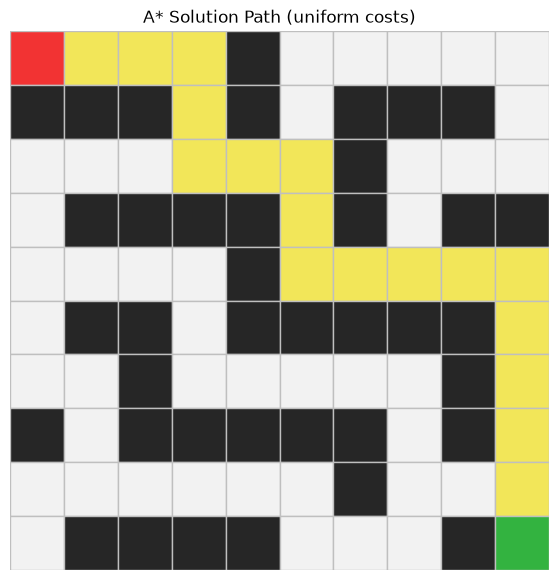

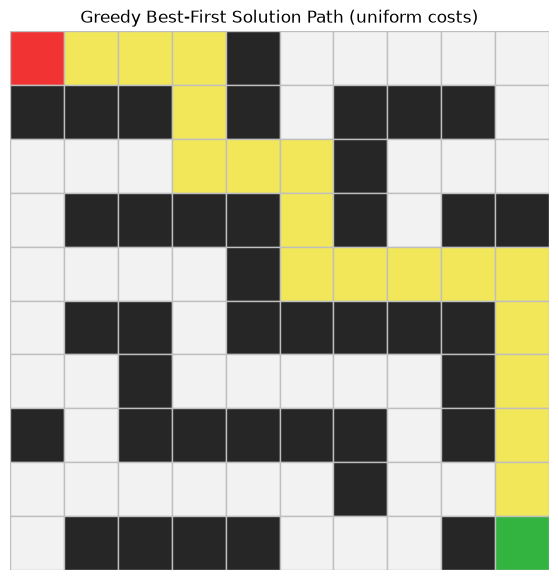

In [85]:
plot_path(
    sample_grid,
    start,
    goal,
    path=uniform_results[1].path,
    title="A* Solution Path (uniform costs)",
)

plot_path(
    sample_grid,
    start,
    goal,
    path=uniform_results[3].path,
    title="Greedy Best-First Solution Path (uniform costs)",
)
     

In [86]:
turbulence_grid = [
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
]

turbulence_costs = [
    [1, 1, 1, 1, 1, 1, 1],
    [1, 1, 9, 9, 9, 1, 1],
    [1, 1, 9, 9, 9, 1, 1],
    [1, 1, 9, 9, 9, 1, 1],
    [1, 1, 1, 1, 1, 1, 1],
]

t_start = (2, 0)
t_goal = (2, 6)

turbulence_problem = WeightedGridProblem(
    turbulence_grid, t_start, t_goal, terrain_costs=turbulence_costs
)

turbulence_results = [
    ucs.search(turbulence_problem),
    astar.search(turbulence_problem),
    wastar2.search(turbulence_problem),
    greedy.search(turbulence_problem),
]

show_results(turbulence_results)
     

,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,UniformCostSearch,success,10,10,26,12,35
1,AStarSearch,success,10,10,25,12,34
2,WeightedAStarSearch,success,10,10,13,13,26
3,GreedyBestFirstSearch,success,6,30,6,13,19


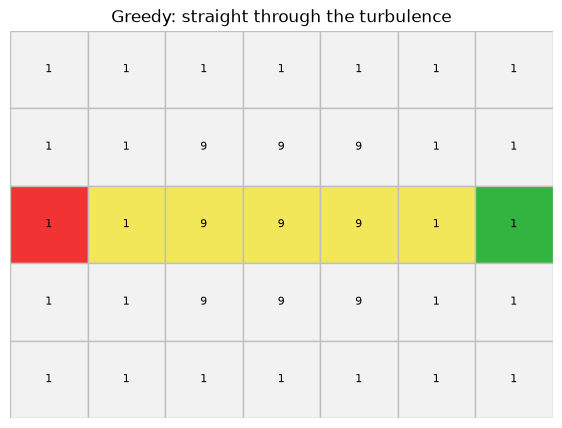

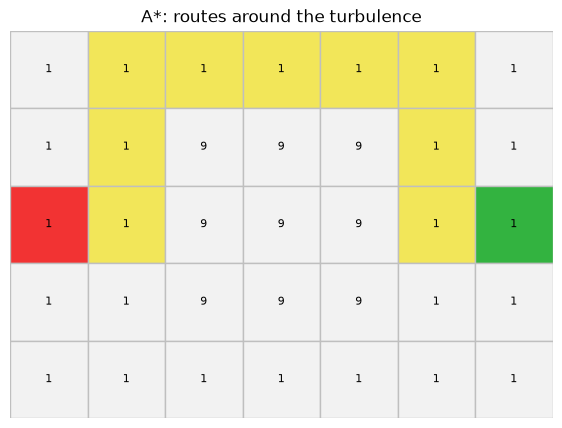

In [87]:
# Greedy vs A* on the turbulence map. The numbers printed in each cell
# are the terrain costs.
plot_path(
    turbulence_grid,
    t_start,
    t_goal,
    path=turbulence_results[3].path,
    terrain_costs=turbulence_costs,
    title="Greedy: straight through the turbulence",
)

plot_path(
    turbulence_grid,
    t_start,
    t_goal,
    path=turbulence_results[1].path,
    terrain_costs=turbulence_costs,
    title="A*: routes around the turbulence",
)

In [88]:
def inflated_heuristic(factor: float):
    # TODO 8:
    # Return a NEW heuristic function that overestimates by multiplying
    # Manhattan distance by `factor`.
    #
    # Steps:
    # 1. Define an inner function h(state, goal) that returns
    #    factor * manhattan_distance(state, goal).
    # 2. Return the inner function (do not call it).
    #
    # Hint: this is a closure —
    # def h(state, goal):
    #     return ...
    # return h

    def h(state, goal):
        return factor * manhattan_distance(state, goal)

    return h


# Once TODO 8 is complete, run the comparison.
#
# The "mild turbulence" map below is designed to expose the inflated
# heuristic: the direct route through the cost-3 band costs 12, while the
# calm detour costs 10. An overconfident heuristic charges straight ahead.

mild_grid = [
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
]

mild_costs = [
    [1, 1, 1, 1, 1, 1, 1],
    [1, 1, 3, 3, 3, 1, 1],
    [1, 1, 3, 3, 3, 1, 1],
    [1, 1, 3, 3, 3, 1, 1],
    [1, 1, 1, 1, 1, 1, 1],
]

mild_problem = WeightedGridProblem(
    mild_grid, (2, 0), (2, 6), terrain_costs=mild_costs
)

astar_honest = AStarSearch(manhattan_distance)
astar_inflated = AStarSearch(inflated_heuristic(3.0))

experiment_results = [
    astar_honest.search(uniform_problem),
    astar_inflated.search(uniform_problem),
    astar_honest.search(mild_problem),
    astar_inflated.search(mild_problem),
]

# Relabel rows so the table is readable.
experiment_results[0].algorithm = "A* admissible (uniform map)"
experiment_results[1].algorithm = "A* inflated x3 (uniform map)"
experiment_results[2].algorithm = "A* admissible (mild turbulence)"
experiment_results[3].algorithm = "A* inflated x3 (mild turbulence)"

show_results(experiment_results)

,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,A* admissible (uniform map),success,18,18,18,5,23
1,A* inflated x3 (uniform map),success,18,18,18,5,23
2,A* admissible (mild turbulence),success,10,10,29,10,35
3,A* inflated x3 (mild turbulence),success,6,12,6,13,19


In [89]:
class IDAStarSearch(SearchAlgorithm):
    algorithm_name = "IDA*"

    def __init__(self, heuristic):
        self.heuristic = heuristic

    def search(self, problem: Problem, max_iterations: int = 200):

        # ---------- helper ----------
        def h(state):
            return self.heuristic(state, problem.goal)

        start_state = problem.initial_state()
        start_node = Node(state=start_state)
        start_cost = h(start_state)

        limit = start_cost

        nodes_expanded = 0
        max_frontier_size = 0
        iterations_log = []

        # ---------- recursive DFS with cost limit ----------
        def dfs(node, g, limit, path_set):
            nonlocal nodes_expanded, max_frontier_size

            f = g + h(node.state)

            if f > limit:
                return f, None  # cutoff value

            if problem.is_goal(node.state):
                return f, node

            nodes_expanded += 1
            max_frontier_size = max(max_frontier_size, len(path_set))

            min_threshold = float("inf")

            for action in problem.actions(node.state):
                child_state = problem.result(node.state, action)

                if child_state in path_set:
                    continue  # cycle check

                child = Node(
                    state=child_state,
                    parent=node,
                    action=action,
                    path_cost=g + problem.action_cost(node.state, action, child_state)
                )

                path_set.add(child_state)

                t, result = dfs(child, child.path_cost, limit, path_set)

                path_set.remove(child_state)

                if result is not None:
                    return t, result

                min_threshold = min(min_threshold, t)

            return min_threshold, None

        # ---------- main IDA* loop ----------
        for i in range(max_iterations):

            iterations_log.append({"limit": limit, "status": "running"})

            path_set = {start_state}

            threshold, result = dfs(start_node, 0, limit, path_set)

            if result is not None:
                return SearchResult(
                    algorithm=self.algorithm_name,
                    status="success",
                    solution=result,
                    nodes_expanded=nodes_expanded,
                    max_frontier_size=max_frontier_size,
                    reached_count=0,
                    iterations=iterations_log
                )

            if threshold == float("inf"):
                iterations_log.append({"limit": threshold, "status": "failure"})
                break

            limit = threshold

        return SearchResult(
            algorithm=self.algorithm_name,
            status="cutoff",
            solution=None,
            nodes_expanded=nodes_expanded,
            max_frontier_size=max_frontier_size,
            reached_count=0,
            iterations=iterations_log
        )

In [90]:
# TODO 10:
# Create your first custom map here.

custom_grid_1 = [
    [0, 0, 0, 0, 0],
    [0, 1, 1, 1, 0],
    [0, 0, 0, 1, 0],
    [1, 1, 0, 0, 0],
    [0, 0, 0, 0, 0],
]

custom_costs_1 = [
    [1, 1, 1, 1, 1],
    [1, 0, 0, 0, 1],  # obstacles ignored (0 won't be used)
    [1, 1, 3, 0, 1],
    [0, 0, 3, 2, 1],
    [1, 1, 1, 1, 1],
]

custom_start_1 = (0, 0)
custom_goal_1 = (4, 4)

custom_problem_1 = WeightedGridProblem(
    custom_grid_1,
    custom_start_1,
    custom_goal_1,
    terrain_costs=custom_costs_1
)

custom_results_1 = [
    GreedyBestFirstSearch(manhattan_distance).search(custom_problem_1),
    AStarSearch(manhattan_distance).search(custom_problem_1),
    WeightedAStarSearch(manhattan_distance, weight=2).search(custom_problem_1),
]

show_results(custom_results_1)

,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,GreedyBestFirstSearch,success,8,12,8,4,12
1,AStarSearch,success,8,8,11,3,14
2,WeightedAStarSearch,success,8,8,12,3,15


In [91]:
# TODO 11:
# Create your second custom map here.

custom_grid_2 = [
    [0, 0, 0, 0, 0, 0],
    [0, 1, 1, 1, 1, 0],
    [0, 0, 0, 0, 1, 0],
    [0, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0],
]

custom_costs_2 = [
    [1, 1, 1, 1, 1, 1],
    [1, 0, 0, 0, 0, 1],
    [1, 2, 2, 2, 0, 1],
    [1, 0, 0, 3, 0, 1],
    [1, 1, 1, 1, 1, 1],
]

custom_start_2 = (0, 0)
custom_goal_2 = (4, 5)

custom_problem_2 = WeightedGridProblem(
    custom_grid_2,
    custom_start_2,
    custom_goal_2,
    terrain_costs=custom_costs_2
)

custom_results_2 = [
    GreedyBestFirstSearch(manhattan_distance).search(custom_problem_2),
    AStarSearch(manhattan_distance).search(custom_problem_2),
    WeightedAStarSearch(manhattan_distance, weight=2).search(custom_problem_2),
]

show_results(custom_results_2)

,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,GreedyBestFirstSearch,success,9,9,9,4,13
1,AStarSearch,success,9,9,17,4,20
2,WeightedAStarSearch,success,9,9,9,4,13


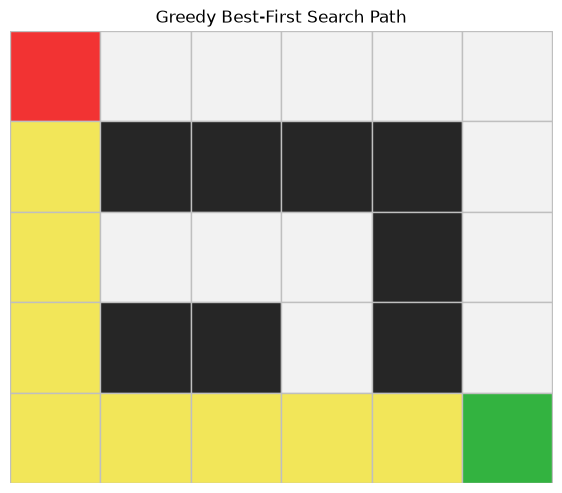

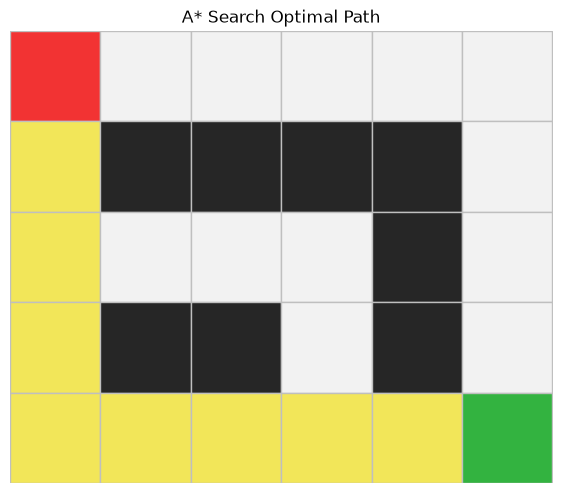

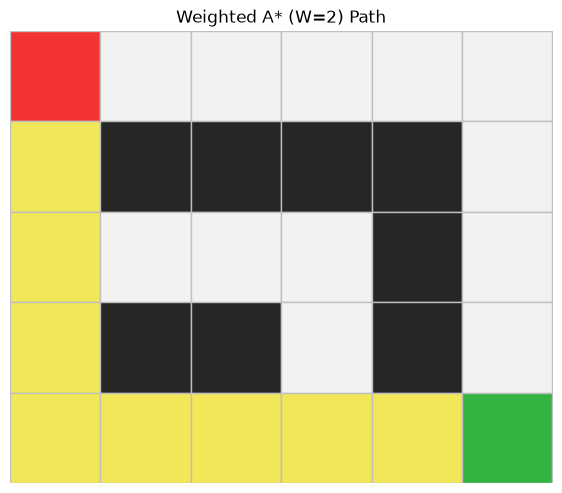

In [92]:

greedy = GreedyBestFirstSearch(manhattan_distance)
astar = AStarSearch(manhattan_distance)
wastar = WeightedAStarSearch(manhattan_distance, weight=2)



results = [
    greedy.search(custom_problem_2),
    astar.search(custom_problem_2),
    wastar.search(custom_problem_2),
]


show_results(results)



greedy_path = results[0].path
astar_path = results[1].path
wastar_path = results[2].path


plot_path(
    custom_grid_2,
    start=custom_start_2,
    goal=custom_goal_2,
    path=greedy_path,
    title="Greedy Best-First Search Path"
)

plot_path(
    custom_grid_2,
    start=custom_start_2,
    goal=custom_goal_2,
    path=astar_path,
    title="A* Search Optimal Path"
)

plot_path(
    custom_grid_2,
    start=custom_start_2,
    goal=custom_goal_2,
    path=wastar_path,
    title="Weighted A* (W=2) Path"
)

16.1 Heuristic Functions
1. What does h(n) estimate and where does its knowledge come from?
h(n) estimates the cost from the current state to the goal.
Its knowledge comes from the grid geometrynot from actual terrain costs

2. What restrictions does Manhattan relaxation remove?
It removes: obstacles and terrain costs by assuming uniform cost = 1 per move
So it assumes the drone can move freely in a clean grid.


Manhattan dominates Euclidean in grid movement.
Manhattan ≥ Euclidean. Euclidean expands fewer nodes in theory
but both are admissible, so A* still finds optimal path


If costs are ≥ 1:

Manhattan never overestimates real cost

If cost = 0.5:
Manhattan may overestimate and becomes inadmissible
A* may lose optimality

16.2 Greedy Best-First Search

Greedy ignores g(n) only looks closest to goal so it enters high-cost terrain 


2. Greedy expanded fewer nodes than A* on some maps. Why is that not enough to call it the better algorithm?

Because: it may find non optimal paths so fewer nodes not better solution

3. When is Greedy acceptable?

When speed matters more than accuracy
example: drone quickly reaching a close location for scanning
or real time emergency navigation

16.3 A Search*
1. Meaning of f(n) = g(n) + h(n)
A* chooses paths based on total estimated cost = cost already spent + estimated remaining cost, so it plans: cheap so far AND promising toward goal
2. Why must A* apply the goal test when a node is popped rather than when it is generated? What could go wrong with an early goal test on the turbulence map?

Because: a goal generated early may not be cheapest, a cheaper path may still exist in frontier


3. Why does reached need to be a dictionary (state → best node) in this lab, when a plain set was enough for BFS in Part A?

Because: same state can be reached with different costs




4. Compare the nodes expanded by UCS and A* on the sample map. What does this gap tell you about the value of the heuristic?

UCS explores blindly by cost
A* uses heuristic guidance

So A* expands:

fewer nodes
more directed search

This shows heuristic improves efficiency

16.4 State the definitions of admissible and consistent. Which implies which?
1. 
Admissible: heuristic never overestimates true cost
Consistent: h(n) ≤ cost + h(n')

Consistency implies admissibility

2. What did your inadmissible-heuristic experiment show about the lecture's optimality claim?

It showed optimality depends on admissibility.

3. Is Manhattan distance consistent on our unit-cost grid? Check the triangle inequality h(n) ≤ c(n, a, n') + h(n') for a single move and explain.

Yes.

For one move:

h(n) ≤ 1 + h(n'). This works because moving one step reduces Manhattan distance by 1, so it satisfies triangle inequality

16.5
How does the weight W interpolate between UCS, A*, and Greedy?

2. What suboptimality bound does Weighted A* guarantee, and did your experiments stay well inside that bound?

Weighted A* guarantees:

solution cost ≤ W × optimal cost

3. The drone has 90 seconds of battery margin and the flight computer is slow. Which algorithm and which W would you choose, and why?

If 90 seconds battery limit slow computer
Weighted A* with W = 1.5 or 2
because it is faster than A* and close to optimal

16.6 
1. Which data structures make A* memory-hungry? How does IDA* (bonus) avoid this, and what does it pay instead?

A* stores full frontier, reached dictionary
So memory grows large.

2. In a real drone application, what information would you fold into the terrain costs that this lab leaves out (weather forecasts, no-fly zones that change over time, battery state)?

weather 
battery level
temporary obstacles
signal loss areas

3. Our heuristic assumes the goal never moves. What breaks if the drone is tracking a moving target, and which lecture concepts (e.g., learned heuristics, real-time search) become relevant?

Heuristic becomes invalid because:
goal position changes, A* no longer guarantees correctness and needs real-time search, adaptive heuristics

4. Which single algorithm from Parts A and B combined would you ship on the drone, and under what conditions would you reconsider?

Best choice A* for accuracy critical missions and Weighted A* for real-time constraints.
when environment is dynamic memory is limited
